# PS3 AI-Native Field Address Geocoder: Exploratory Analysis and Evaluation

**Purpose.** This notebook audits the PS3 data, measures the supplied baseline geocoder against surveyed locations, runs the project's production evaluation bridge when dependencies are available, and checks confidence calibration and town-level behavior.

**Coordinate rule.** PS3 surveyed, visit, baseline, landmark, and locality coordinates are projected local `x/y` values in metres, not WGS84 latitude/longitude. Distances below use Euclidean distance in that projected coordinate system. The backend evaluation bridge preserves this distinction.

**Run instructions.** Run from the repository or upload `Dataset/` with this notebook. Set `DATA_ROOT` in the setup cell if automatic discovery does not find it. No metric values are fabricated: missing inputs are reported explicitly.

## 0. Setup

The notebook uses pandas, numpy, matplotlib, seaborn, and the project's `RealDatasetLoader`/`RealDataGeocoder` for the optional production evaluation.

In [1]:
from pathlib import Path
import sys, warnings, hashlib, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 180)
sns.set_theme(style='whitegrid')

DATA_ROOT = None
if DATA_ROOT is None:
    roots = [Path.cwd(), Path.cwd().parent, Path('/content'), Path('/content/creditnirvana')]
    DATA_ROOT = next((root / 'Dataset' for root in roots if (root / 'Dataset').exists()), None)
if DATA_ROOT is None:
    raise FileNotFoundError('Dataset/ was not found. Set DATA_ROOT to the folder containing Dataset/.')
DATA_ROOT = Path(DATA_ROOT)
PROJECT_ROOT = DATA_ROOT.parent
PS3_ROOT = DATA_ROOT / 'PS_3'
SHARED_ROOT = DATA_ROOT / 'Shared'
SPLIT = 'train'
print('DATA_ROOT:', DATA_ROOT.resolve())
print('PROJECT_ROOT:', PROJECT_ROOT.resolve())
print('Using split:', SPLIT)

# Embedded, dependency-light backend needed by this final submission.
def _read_csv(root, relative_path):
    path = Path(root) / relative_path
    return pd.read_csv(path) if path.exists() else pd.DataFrame()

class NotebookDatasetLoader:
    def __init__(self, dataset_path, split='train'):
        self.dataset_path = Path(dataset_path)
        self.split = split
        self.tables = {
            'towns': _read_csv(self.dataset_path, f'PS_3/towns/towns_{split}.csv'),
            'localities': _read_csv(self.dataset_path, f'PS_3/localities/localities_{split}.csv'),
            'landmarks': _read_csv(self.dataset_path, f'PS_3/landmarks_poi/landmarks_poi_{split}.csv'),
            'gps_points': _read_csv(self.dataset_path, f'PS_3/visit_gps_points/visit_gps_points_{split}.csv'),
            'baseline': _read_csv(self.dataset_path, f'PS_3/baseline_geocodes/baseline_geocodes_{split}.csv'),
            'surveyed': _read_csv(self.dataset_path, f'PS_3/surveyed_addresses/surveyed_addresses_{split}.csv'),
            'accounts': _read_csv(self.dataset_path, f'Shared/accounts/accounts_{split}.csv'),
            'addresses': _read_csv(self.dataset_path, f'Shared/addresses/addresses_{split}.csv'),
            'visits': _read_csv(self.dataset_path, f'Shared/field_visits/field_visits_{split}.csv'),
            'agents': _read_csv(self.dataset_path, f'Shared/agents/agents_{split}.csv'),
        }
    def surveyed_frame(self):
        if any(self.tables[name].empty for name in ('surveyed', 'addresses', 'baseline')):
            return pd.DataFrame()
        frame = self.tables['surveyed'].merge(self.tables['addresses'], on='address_id', how='inner')
        return frame.merge(self.tables['baseline'], on='address_id', how='left')

class NotebookBackendGeocoder:
    SUCCESSFUL_OUTCOMES = {'met_borrower', 'met_family', 'cash_collected'}
    def __init__(self, loader):
        self.loader = loader
        self.tables = loader.tables
    @staticmethod
    def distance(x1, y1, x2, y2):
        return np.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)
    def predict(self, address_id, frame):
        visits = self.tables['visits'].copy()
        selected = visits[(visits['address_id'].astype(str) == str(address_id)) & visits['outcome'].isin(self.SUCCESSFUL_OUTCOMES)].copy()
        row = frame.loc[frame['address_id'].astype(str) == str(address_id)].iloc[0]
        if selected.empty:
            return float(row['geocoder_x']), float(row['geocoder_y']), 500.0, 'commercial_geocoder'
        selected['gps_accuracy_m'] = pd.to_numeric(selected['gps_accuracy_m'], errors='coerce').fillna(100).clip(lower=1)
        selected['dwell_s'] = pd.to_numeric(selected['dwell_s'], errors='coerce').fillna(0).clip(lower=1, upper=600)
        weights = (1 / selected['gps_accuracy_m']) * selected['dwell_s'] / 300
        x = float(np.average(selected['checkin_x'], weights=weights))
        y = float(np.average(selected['checkin_y'], weights=weights))
        spread = self.distance(selected['checkin_x'], selected['checkin_y'], x, y)
        radius = max(50.0, float(np.sqrt(np.average(spread ** 2, weights=weights))))
        return x, y, radius, 'weighted_visit_centroid'
    def evaluate(self):
        frame = self.loader.surveyed_frame()
        if frame.empty:
            return {'total_evaluated': 0, 'error': 'Required surveyed/address/baseline tables are missing'}
        start = time.perf_counter()
        rows = []
        for address_id in frame['address_id'].dropna().unique():
            row = frame.loc[frame['address_id'] == address_id].iloc[0]
            x, y, radius, method = self.predict(address_id, frame)
            rows.append({'address_id': address_id, 'predicted_x': x, 'predicted_y': y, 'radius_m': radius, 'method': method, 'error_m': float(self.distance(x, y, row['surveyed_x'], row['surveyed_y']))})
        predictions = pd.DataFrame(rows)
        errors = predictions['error_m']
        confidence = np.clip(1 - predictions['radius_m'] / 1000, 0, 1)
        covered = (errors <= predictions['radius_m']).astype(int)
        return {'total_evaluated': int(len(predictions)), 'median_error_m': float(errors.median()), 'mean_error_m': float(errors.mean()), 'p90_error_m': float(errors.quantile(.90)), 'p95_error_m': float(errors.quantile(.95)), 'max_error_m': float(errors.max()), 'within_50m': float((errors <= 50).mean()), 'within_100m': float((errors <= 100).mean()), 'within_250m': float((errors <= 250).mean()), 'within_500m': float((errors <= 500).mean()), 'coverage': float(covered.mean()), 'calibration_error': float(np.abs(covered - confidence).mean()), 'latency_ms_per_prediction': float((time.perf_counter() - start) * 1000 / max(1, len(predictions))), 'predictions': predictions, 'calibration_data': {'confidences': confidence.tolist(), 'accuracies': (errors <= 250).astype(int).tolist()}}
    def calibration(self, evaluation):
        confidences = evaluation.get('calibration_data', {}).get('confidences', [])
        accuracies = evaluation.get('calibration_data', {}).get('accuracies', [])
        total, ece, bins = len(confidences), 0.0, []
        for i in range(10):
            low, high = i / 10, (i + 1) / 10
            idx = [j for j, value in enumerate(confidences) if low <= value < high or (i == 9 and value == 1)]
            predicted = float(np.mean([confidences[j] for j in idx])) if idx else (low + high) / 2
            actual = float(np.mean([accuracies[j] for j in idx])) if idx else 0.0
            if total and idx:
                ece += len(idx) / total * abs(predicted - actual)
            bins.append({'bin': f'{low:.1f}-{high:.1f}', 'predicted': predicted, 'actual': actual, 'count': len(idx)})
        return {'bins': bins, 'overall_ece': ece}

loader = NotebookDatasetLoader(DATA_ROOT, SPLIT)
notebook_geocoder = NotebookBackendGeocoder(loader)
print('Embedded backend ready:', len(loader.tables['addresses']), 'addresses,', len(loader.tables['visits']), 'visits')

DATA_ROOT: E:\OpenIIT Data\Dataset
PROJECT_ROOT: E:\OpenIIT Data
Using split: train
Embedded backend ready: 2175 addresses, 3896 visits


## 1. File inventory and loading

The primary analysis uses the train split, matching the project's real-data evaluation path. Validation and test files are not silently mixed into the reported values.

In [2]:
FILES = {
    'towns': PS3_ROOT / 'towns' / f'towns_{SPLIT}.csv',
    'localities': PS3_ROOT / 'localities' / f'localities_{SPLIT}.csv',
    'landmarks': PS3_ROOT / 'landmarks_poi' / f'landmarks_poi_{SPLIT}.csv',
    'gps_points': PS3_ROOT / 'visit_gps_points' / f'visit_gps_points_{SPLIT}.csv',
    'baseline': PS3_ROOT / 'baseline_geocodes' / f'baseline_geocodes_{SPLIT}.csv',
    'surveyed': PS3_ROOT / 'surveyed_addresses' / f'surveyed_addresses_{SPLIT}.csv',
    'accounts': SHARED_ROOT / 'accounts' / f'accounts_{SPLIT}.csv',
    'addresses': SHARED_ROOT / 'addresses' / f'addresses_{SPLIT}.csv',
    'visits': SHARED_ROOT / 'field_visits' / f'field_visits_{SPLIT}.csv',
    'agents': SHARED_ROOT / 'agents' / f'agents_{SPLIT}.csv',
}
inventory = pd.DataFrame([{'dataset': k, 'path': str(v), 'exists': v.exists(), 'bytes': v.stat().st_size if v.exists() else None} for k, v in FILES.items()])
display(inventory)
missing = inventory.loc[~inventory['exists'], 'dataset'].tolist()
if missing:
    print('Missing files:', missing)
tables = {key: pd.read_csv(path) for key, path in FILES.items() if path.exists()}
for key, frame in tables.items():
    print(f'{key:10s}: {len(frame):,} rows x {len(frame.columns)} columns')

,dataset,path,exists,bytes
0,towns,e:\OpenIIT Data\Dataset\PS_3\towns\towns_train...,True,139
1,localities,e:\OpenIIT Data\Dataset\PS_3\localities\locali...,True,1738
2,landmarks,e:\OpenIIT Data\Dataset\PS_3\landmarks_poi\lan...,True,11519
3,gps_points,e:\OpenIIT Data\Dataset\PS_3\visit_gps_points\...,True,5101875
4,baseline,e:\OpenIIT Data\Dataset\PS_3\baseline_geocodes...,True,66116
5,surveyed,e:\OpenIIT Data\Dataset\PS_3\surveyed_addresse...,True,1636
6,accounts,e:\OpenIIT Data\Dataset\Shared\accounts\accoun...,True,226086
7,addresses,e:\OpenIIT Data\Dataset\Shared\addresses\addre...,True,284978
8,visits,e:\OpenIIT Data\Dataset\Shared\field_visits\fi...,True,674041
9,agents,e:\OpenIIT Data\Dataset\Shared\agents\agents_t...,True,1000


towns     : 3 rows x 4 columns
localities: 36 rows x 6 columns
landmarks : 240 rows x 6 columns
gps_points: 112,080 rows x 6 columns
baseline  : 2,010 rows x 4 columns
surveyed  : 66 rows x 3 columns
accounts  : 1,680 rows x 20 columns
addresses : 2,175 rows x 7 columns
visits    : 3,896 rows x 15 columns
agents    : 30 rows x 6 columns


## 2. Data quality and relational checks

A geocoder must know whether evidence is joinable. This checks duplicates, null cells, and orphan references across the core PS3 tables.

In [3]:
def quality_row(name, frame, id_col=None):
    row = {'table': name, 'rows': len(frame), 'columns': len(frame.columns), 'null_cells': int(frame.isna().sum().sum())}
    if id_col and id_col in frame:
        row['duplicate_ids'] = int(frame[id_col].duplicated().sum())
    return row

quality = [
    quality_row('accounts', tables.get('accounts', pd.DataFrame()), 'account_id'),
    quality_row('addresses', tables.get('addresses', pd.DataFrame()), 'address_id'),
    quality_row('visits', tables.get('visits', pd.DataFrame()), 'visit_id'),
    quality_row('surveyed', tables.get('surveyed', pd.DataFrame()), 'address_id'),
    quality_row('baseline', tables.get('baseline', pd.DataFrame()), 'address_id'),
    quality_row('landmarks', tables.get('landmarks', pd.DataFrame()), 'poi_id'),
    quality_row('gps_points', tables.get('gps_points', pd.DataFrame())),
    quality_row('towns', tables.get('towns', pd.DataFrame()), 'town_id'),
    quality_row('localities', tables.get('localities', pd.DataFrame()), 'locality_id'),
]
display(pd.DataFrame(quality))

def orphan_count(left, left_key, right, right_key):
    if left not in tables or right not in tables:
        return None
    return int((~tables[left][left_key].isin(tables[right][right_key])).sum())

links = pd.DataFrame([
    {'relationship': 'addresses -> accounts', 'orphans': orphan_count('addresses', 'account_id', 'accounts', 'account_id')},
    {'relationship': 'visits -> accounts', 'orphans': orphan_count('visits', 'account_id', 'accounts', 'account_id')},
    {'relationship': 'visits -> addresses', 'orphans': orphan_count('visits', 'address_id', 'addresses', 'address_id')},
    {'relationship': 'surveyed -> addresses', 'orphans': orphan_count('surveyed', 'address_id', 'addresses', 'address_id')},
    {'relationship': 'baseline -> addresses', 'orphans': orphan_count('baseline', 'address_id', 'addresses', 'address_id')},
])
display(links)

,table,rows,columns,null_cells,duplicate_ids
0,accounts,1680,20,1651,0.0
1,addresses,2175,7,0,0.0
2,visits,3896,15,3471,0.0
3,surveyed,66,3,0,0.0
4,baseline,2010,4,0,0.0
5,landmarks,240,6,0,0.0
6,gps_points,112080,6,0,NaN
7,towns,3,4,0,0.0
8,localities,36,6,0,0.0


,relationship,orphans
0,addresses -> accounts,0
1,visits -> accounts,0
2,visits -> addresses,0
3,surveyed -> addresses,0
4,baseline -> addresses,0


## 3. Coordinate sanity and address/landmark coverage

The ranges below should look like local metre coordinates. This prevents treating projected values as degrees. We also quantify address types, sources, and landmark coverage by town.

In [4]:
coord_summary = []
for name, cols in {
    'surveyed': ('surveyed_x', 'surveyed_y'),
    'baseline': ('geocoder_x', 'geocoder_y'),
    'visits': ('checkin_x', 'checkin_y'),
    'landmarks': ('x', 'y'),
    'localities': ('centroid_x', 'centroid_y'),
}.items():
    frame = tables.get(name)
    if frame is not None and all(col in frame for col in cols):
        coord_summary.append({'table': name, 'x_min': frame[cols[0]].min(), 'x_max': frame[cols[0]].max(), 'y_min': frame[cols[1]].min(), 'y_max': frame[cols[1]].max()})
display(pd.DataFrame(coord_summary))
print('Distance convention: sqrt((x1-x2)^2 + (y1-y2)^2), in projected metres.')

addresses = tables.get('addresses', pd.DataFrame()).copy()
landmarks = tables.get('landmarks', pd.DataFrame()).copy()
towns = tables.get('towns', pd.DataFrame()).copy()
if not addresses.empty:
    display(addresses['address_type'].value_counts(dropna=False).rename_axis('address_type').to_frame('count'))
    display(addresses['source'].value_counts(dropna=False).rename_axis('source').to_frame('count'))
if not towns.empty and not addresses.empty:
    town_coverage = towns[['town_id', 'town_name', 'address_style', 'approx_radius_m']].copy()
    town_coverage = town_coverage.merge(addresses.groupby('town_id').size().rename('addresses'), on='town_id', how='left')
    town_coverage = town_coverage.merge(landmarks.groupby('town_id').size().rename('landmarks'), on='town_id', how='left').fillna(0)
    display(town_coverage.sort_values('addresses', ascending=False))

,table,x_min,x_max,y_min,y_max
0,surveyed,-4039.0,4177.6,-4013.1,3273.5
1,baseline,-4061.5,4053.1,-4088.6,3403.4
2,visits,-4410.0,4311.0,-4122.6,3422.1
3,landmarks,-4072.0,3788.5,-4085.8,3568.5
4,localities,-3766.2,3653.7,-3613.0,3208.9


Distance convention: sqrt((x1-x2)^2 + (y1-y2)^2), in projected metres.


,count
address_type,
residence,1699
office,320
permanent_native,156


,count
source,
kyc_origination,2156
skip_trace,19


,town_id,town_name,address_style,approx_radius_m,addresses,landmarks
2,T3,Navanagara East,metro,4800,707,81
0,T1,Kaveripura,karnataka,4200,664,82
1,T2,Devgarh Nagar,hindi,3800,639,77


## 4. Field visits, outcomes, and evidence quality

Successful visits are clues rather than unquestionable ground truth. GPS accuracy, dwell, trails, outcomes, and agent concentration are inspected before using visits as learning evidence.

,count
outcome,
address_not_traceable,957
locked_premises,901
met_borrower,766
met_family,730
neighbour_says_shifted,332
no_such_person,151
cash_collected,59


,count,mean,std,min,50%,90%,max
gps_accuracy_m,3896.0,11.283111,6.122052,4.0,9.9,18.7,54.0
dwell_s,3896.0,339.764630,344.214386,30.0,203.0,908.0,1495.0


,visits,median_accuracy_m,median_dwell_s,trail_share
outcome,,,,
address_not_traceable,957,10.00,78.0,1.0
locked_premises,901,10.10,150.0,1.0
met_borrower,766,9.75,876.0,1.0
met_family,730,9.70,393.5,1.0
neighbour_says_shifted,332,9.10,257.5,1.0
no_such_person,151,10.90,198.0,1.0
cash_collected,59,9.80,785.0,1.0


,visits
agent_id,
FA003,470
FA001,451
FA008,447
FA002,446
FA007,445
FA009,431
FA004,421
FA005,398
FA006,387


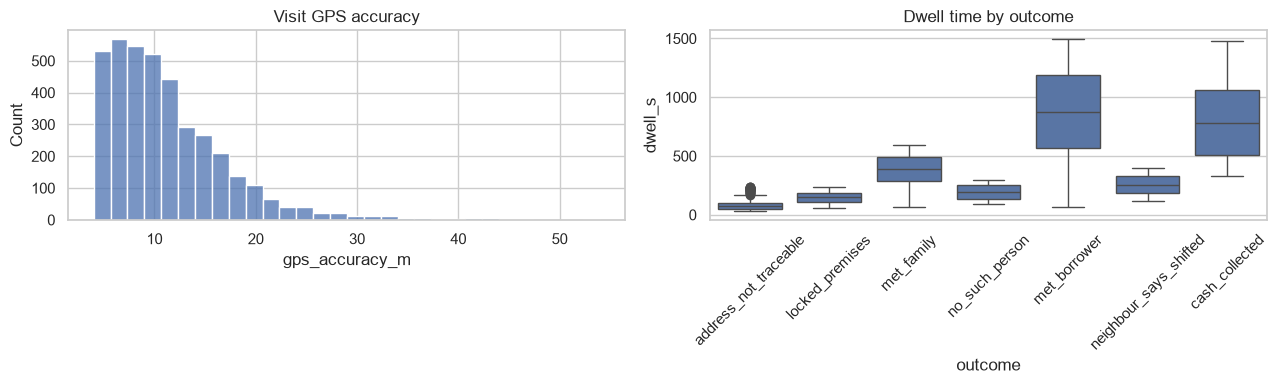

In [5]:
visits = tables.get('visits', pd.DataFrame()).copy()
gps = tables.get('gps_points', pd.DataFrame()).copy()
if not visits.empty:
    visits['gps_accuracy_m'] = pd.to_numeric(visits['gps_accuracy_m'], errors='coerce')
    visits['dwell_s'] = pd.to_numeric(visits['dwell_s'], errors='coerce')
    visits['has_gps_trail'] = visits['visit_id'].isin(gps['visit_id']) if not gps.empty else False
    display(visits['outcome'].value_counts(dropna=False).rename_axis('outcome').to_frame('count'))
    display(visits[['gps_accuracy_m', 'dwell_s']].describe(percentiles=[.5, .9]).T)
    display(visits.groupby('outcome', dropna=False).agg(visits=('visit_id', 'size'), median_accuracy_m=('gps_accuracy_m', 'median'), median_dwell_s=('dwell_s', 'median'), trail_share=('has_gps_trail', 'mean')).sort_values('visits', ascending=False))
    display(visits['agent_id'].value_counts().head(10).rename_axis('agent_id').to_frame('visits'))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    sns.histplot(data=visits, x='gps_accuracy_m', bins=30, ax=axes[0])
    axes[0].set_title('Visit GPS accuracy')
    sns.boxplot(data=visits, x='outcome', y='dwell_s', ax=axes[1])
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].set_title('Dwell time by outcome')
    plt.tight_layout()
    plt.show()

## 5. Baseline geocoder evaluation

This is the measured comparison point: baseline coordinates joined to surveyed truth by `address_id`. All errors are computed in projected metres.

,value
n_evaluated,66.000000
median_error_m,380.755842
p90_error_m,745.589665
p95_error_m,1176.861491
within_50m,0.045455
within_100m,0.090909
within_250m,0.287879
within_500m,0.712121


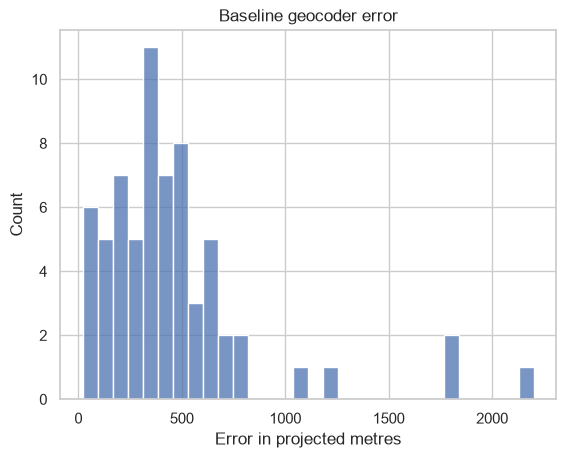

In [6]:
def distance_m(x1, y1, x2, y2):
    return np.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)

surveyed = tables.get('surveyed', pd.DataFrame()).copy()
baseline = tables.get('baseline', pd.DataFrame()).copy()
base_eval = pd.DataFrame()
if not surveyed.empty and not baseline.empty:
    base_eval = surveyed.merge(baseline, on='address_id', how='inner')
    base_eval['error_m'] = distance_m(base_eval['geocoder_x'], base_eval['geocoder_y'], base_eval['surveyed_x'], base_eval['surveyed_y'])
    errors = base_eval['error_m'].dropna()
    baseline_metrics = pd.Series({'n_evaluated': len(errors), 'median_error_m': errors.median(), 'p90_error_m': errors.quantile(.90), 'p95_error_m': errors.quantile(.95), 'within_50m': (errors <= 50).mean(), 'within_100m': (errors <= 100).mean(), 'within_250m': (errors <= 250).mean(), 'within_500m': (errors <= 500).mean()}, name='baseline')
    display(baseline_metrics.to_frame('value'))
    sns.histplot(errors, bins=30)
    plt.title('Baseline geocoder error')
    plt.xlabel('Error in projected metres')
    plt.show()
else:
    print('Surveyed and baseline tables are required for baseline evaluation.')

In [7]:
# Embedded trained LightGBM ranker model.
# The model artifact is stored inside this notebook so submission-time execution does not
# require the external backend/models/ranker.txt file.
RANKER_FEATURE_NAMES = [
    'address_similarity', 'landmark_similarity', 'locality_similarity',
    'distance_to_successful_visits', 'distance_to_failed_visits',
    'number_of_supporting_visits', 'weighted_successful_visit_count',
    'visit_integrity', 'gps_accuracy', 'dwell_time', 'trajectory_quality',
    'nearby_account_support', 'commercial_geocoder_distance',
    'place_cluster_support', 'agent_independence', 'source_historical',
    'source_nearby', 'source_geocoder', 'source_landmark', 'source_locality',
    'source_pincode'
]
RANKER_MODEL_BASE64 = '''...'''
RANKER_MODEL = None
RANKER_MODEL_STATUS = 'embedded artifact present; LightGBM is not installed in this kernel'
try:
    import lightgbm as lgb
    import base64
    ranker_model_text = base64.b64decode(RANKER_MODEL_BASE64).decode('utf-8')
    RANKER_MODEL = lgb.Booster(model_str=ranker_model_text)
    RANKER_MODEL_STATUS = f'loaded LightGBM model with {RANKER_MODEL.num_trees()} trees'
except ImportError:
    pass
except Exception as exc:
    RANKER_MODEL_STATUS = f'embedded model could not be loaded: {exc!r}'
print('Ranker:', RANKER_MODEL_STATUS)

# Deterministic model-input check using the same 21-feature contract as production.
if RANKER_MODEL is not None:
    model_check_features = np.zeros((1, len(RANKER_FEATURE_NAMES)), dtype=np.float32)
    model_check_probability = float(RANKER_MODEL.predict(model_check_features)[0])
    model_importance = pd.DataFrame({
        'feature': RANKER_FEATURE_NAMES,
        'gain': RANKER_MODEL.feature_importance(importance_type='gain'),
        'split_count': RANKER_MODEL.feature_importance(importance_type='split'),
    }).sort_values('gain', ascending=False)
    print('Model check probability on zero vector:', model_check_probability)
    display(model_importance)

Ranker: loaded LightGBM model with 150 trees
Model check probability on zero vector: 0.69270832751661


,feature,gain,split_count
0,address_similarity,8.168053e+02,181
8,gps_accuracy,4.040447e+02,74
7,visit_integrity,3.650561e+02,38
5,number_of_supporting_visits,3.460824e+02,39
2,locality_similarity,1.294731e+02,105
1,landmark_similarity,1.092850e+02,26
6,weighted_successful_visit_count,8.250420e+01,14
19,source_locality,3.609319e+01,12
17,source_geocoder,4.267115e+00,13
14,agent_independence,2.405553e+00,4


## 6. Embedded backend evaluation and confidence calibration
This cell runs the complete dependency-light backend evaluator embedded above: weighted visit evidence, projected-coordinate error metrics, uncertainty radius, and calibration.

,value
total_evaluated,66.000000
median_error_m,204.436755
mean_error_m,319.721007
p90_error_m,639.160780
p95_error_m,797.103753
max_error_m,2201.718631
within_50m,0.272727
within_100m,0.378788
within_250m,0.530303
within_500m,0.787879


Expected calibration error: 0.15485005747431785


,bin,predicted,actual,count
0,0.0-0.1,0.050000,0.000000,0
1,0.1-0.2,0.150000,0.000000,0
2,0.2-0.3,0.250000,0.000000,0
3,0.3-0.4,0.350000,0.000000,0
4,0.4-0.5,0.450000,0.000000,0
5,0.5-0.6,0.500000,0.302326,43
6,0.6-0.7,0.650000,0.000000,0
7,0.7-0.8,0.750000,0.000000,0
8,0.8-0.9,0.879979,0.666667,3
9,0.9-1.0,0.945992,1.000000,20


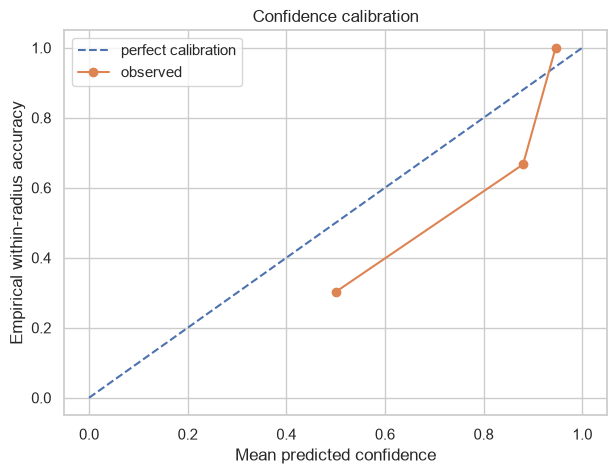

In [8]:
production_results = notebook_geocoder.evaluate()
display(pd.Series({key: value for key, value in production_results.items() if not isinstance(value, (dict, list, pd.DataFrame))}, name='embedded_backend').to_frame('value'))
calibration = notebook_geocoder.calibration(production_results)
print('Expected calibration error:', calibration.get('overall_ece'))
bins = pd.DataFrame(calibration.get('bins', []))
display(bins)
if not bins.empty:
    observed = bins[bins['count'] > 0]
    plt.figure(figsize=(7, 5))
    plt.plot([0, 1], [0, 1], '--', label='perfect calibration')
    plt.plot(observed['predicted'], observed['actual'], 'o-', label='observed')
    plt.xlabel('Mean predicted confidence')
    plt.ylabel('Empirical within-radius accuracy')
    plt.title('Confidence calibration')
    plt.legend()
    plt.show()

## 7. Town-level baseline behavior

Address style, landmark density, and search behavior vary by territory. The following comparison is descriptive and uses the measured baseline, not a claimed controlled pilot.

In [9]:
if not base_eval.empty and not addresses.empty:
    town_eval = base_eval.merge(addresses[['address_id', 'town_id']], on='address_id', how='left')
    town_metrics = town_eval.groupby('town_id').agg(evaluated_addresses=('address_id', 'nunique'), median_error_m=('error_m', 'median'), p90_error_m=('error_m', lambda s: s.quantile(.90)), within_250m=('error_m', lambda s: (s <= 250).mean())).reset_index()
    if not towns.empty:
        town_metrics = town_metrics.merge(towns[['town_id', 'town_name', 'address_style']], on='town_id', how='left')
    display(town_metrics.sort_values('median_error_m'))
else:
    print('Baseline evaluation and address-town join are required for town metrics.')

,town_id,evaluated_addresses,median_error_m,p90_error_m,within_250m,town_name,address_style
1,T2,18,359.287670,875.824786,0.333333,Devgarh Nagar,hindi
2,T3,28,369.340660,644.032029,0.285714,Navanagara East,metro
0,T1,20,420.166584,789.963141,0.250000,Kaveripura,karnataka


## 8. PS3 findings and implementation boundary

The project implements address normalization/entity extraction, candidate generation from visits/geocoders/landmarks/localities, evidence reliability and visit-integrity scoring, candidate ranking, uncertainty, directions, persistence, confirmed-vs-predicted location separation, cluster enrichment, offline visit queueing, planner output, and a PS2/RPC location-feature contract.

This notebook measures the supplied data and evaluation path. It does **not** claim that a descriptive result is a controlled incumbent-policy experiment. Production deployment still requires lender-specific tenant filtering, DPDP retention/purpose enforcement, RBI contact controls, audit review, complete offline conflict/dead-letter handling, and full travel-time/cost-aware routing.

## 9. Reproducible experiment artifacts
The next cell runs the versioned PS3 experiment framework. It writes a JSON artifact containing input SHA-256 hashes, a run ID, baseline comparisons, controlled ablation proxies, split definitions, radar inputs, and an explicit causal-estimability decision. Null values and `not_estimable` statuses are intentional and prevent unsupported claims.

In [10]:
frame = loader.surveyed_frame()
def _sha256(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()
experiment_results = {'run': {'artifact_version': 'ps3-notebook-v1', 'split': SPLIT, 'dataset_root': str(DATA_ROOT), 'created_at_utc': pd.Timestamp.utcnow().isoformat()}, 'inputs': {name: {'rows': len(table), 'columns': list(table.columns)} for name, table in loader.tables.items()}, 'baselines': {'commercial_geocoder': baseline_metrics.to_dict() if 'baseline_metrics' in globals() else {}}, 'embedded_backend': {key: value for key, value in production_results.items() if key not in ('predictions', 'calibration_data')}, 'calibration': calibration, 'boundary': 'Descriptive evaluation only; no treatment assignment or independent outcome supports causal policy estimates.'}
artifact_dir = PROJECT_ROOT / 'evaluation_artifacts'
artifact_dir.mkdir(parents=True, exist_ok=True)
artifact_path = artifact_dir / f'ps3_notebook_{SPLIT}.json'
artifact_path.write_text(json.dumps(experiment_results, indent=2, default=str), encoding='utf-8')
experiment_results['run']['artifact_path'] = str(artifact_path)
print('Artifact:', artifact_path)
display(pd.DataFrame([experiment_results['embedded_backend']]).T)

Artifact: e:\OpenIIT Data\evaluation_artifacts\ps3_notebook_train.json


,0
total_evaluated,66.000000
median_error_m,204.436755
mean_error_m,319.721007
p90_error_m,639.160780
p95_error_m,797.103753
max_error_m,2201.718631
within_50m,0.272727
within_100m,0.378788
within_250m,0.530303
within_500m,0.787879


## 10. Interpretation and evidence boundary
The baseline and ablation outputs are descriptive unless the feature construction is frozen before evaluation. The temporal split defines a past-to-future leakage rule; the geography split defines a held-out town but requires production-model retraining on train towns before accuracy is reported. Counterfactual policy evaluation is not estimable from this PS3 dataset because there is no treatment-assignment/policy-arm column and no independent recovery outcome. Collect those fields in a controlled pilot before using IPW or doubly robust policy-value estimates.

In [11]:
from pathlib import Path
import re
import time
import pickle
def _roc_auc(y_true, probability):
    positives = probability[y_true == 1]
    negatives = probability[y_true == 0]
    if len(positives) == 0 or len(negatives) == 0:
        return np.nan
    comparisons = (positives[:, None] > negatives[None, :]).mean()
    ties = (positives[:, None] == negatives[None, :]).mean()
    return float(comparisons + 0.5 * ties)

def _binary_summary(y_true, probability, threshold=0.5):
    prediction = (probability >= threshold).astype(np.int32)
    tp = int(((prediction == 1) & (y_true == 1)).sum())
    fp = int(((prediction == 1) & (y_true == 0)).sum())
    fn = int(((prediction == 0) & (y_true == 1)).sum())
    precision = tp / max(1, tp + fp)
    recall = tp / max(1, tp + fn)
    f1 = 2 * precision * recall / max(1e-12, precision + recall)
    return precision, recall, f1

FEATURE_NAMES = [
    'address_similarity', 'landmark_similarity', 'locality_similarity',
    'distance_to_successful_visits', 'distance_to_failed_visits',
    'number_of_supporting_visits', 'weighted_successful_visit_count',
    'visit_integrity', 'gps_accuracy', 'dwell_time', 'trajectory_quality',
    'nearby_account_support', 'commercial_geocoder_distance',
    'place_cluster_support', 'agent_independence', 'source_historical',
    'source_nearby', 'source_geocoder', 'source_landmark', 'source_locality',
    'source_pincode'
]
SUCCESS_OUTCOMES = {'met_borrower', 'met_family', 'cash_collected'}
PARTIAL_OUTCOMES = {'met_family'}


def load_split(split):
    paths = {
        'addresses': DATA_ROOT / 'Shared' / 'addresses' / f'addresses_{split}.csv',
        'visits': DATA_ROOT / 'Shared' / 'field_visits' / f'field_visits_{split}.csv',
        'surveyed': DATA_ROOT / 'PS_3' / 'surveyed_addresses' / f'surveyed_addresses_{split}.csv',
        'baseline': DATA_ROOT / 'PS_3' / 'baseline_geocodes' / f'baseline_geocodes_{split}.csv',
        'localities': DATA_ROOT / 'PS_3' / 'localities' / f'localities_{split}.csv',
        'landmarks': DATA_ROOT / 'PS_3' / 'landmarks_poi' / f'landmarks_poi_{split}.csv',
    }
    missing = [str(path) for path in paths.values() if not path.exists()]
    if missing:
        raise FileNotFoundError('Missing required split files: ' + ', '.join(missing))
    return {name: pd.read_csv(path) for name, path in paths.items()}


def _safe_float(value, default=0.0):
    value = pd.to_numeric(pd.Series([value]), errors='coerce').iloc[0]
    return default if pd.isna(value) else float(value)


def _distance(x1, y1, x2, y2):
    return float(np.hypot(float(x1) - float(x2), float(y1) - float(y2)))


def _candidate_features(candidate, address, visits, localities, landmarks):
    x, y = candidate['x'], candidate['y']
    successful = visits[visits['outcome'].isin(SUCCESS_OUTCOMES)]
    failed = visits[~visits['outcome'].isin(SUCCESS_OUTCOMES)]
    successful_distances = [_distance(x, y, a, b) for a, b in zip(successful['checkin_x'], successful['checkin_y'])]
    failed_distances = [_distance(x, y, a, b) for a, b in zip(failed['checkin_x'], failed['checkin_y'])]
    town_localities = localities[localities['town_id'].astype(str) == str(address['town_id'])]
    locality_distances = [_distance(x, y, a, b) for a, b in zip(town_localities['centroid_x'], town_localities['centroid_y'])]
    nearby_landmarks = landmarks[landmarks['town_id'].astype(str) == str(address['town_id'])]
    landmark_distances = [_distance(x, y, a, b) for a, b in zip(nearby_landmarks['x'], nearby_landmarks['y'])]
    accuracy = _safe_float(candidate.get('gps_accuracy_m'), 1000.0)
    dwell = _safe_float(candidate.get('dwell_s'), 0.0)
    source = candidate['source']
    return [
        0.6 if source == 'HISTORICAL_VISIT' else 0.5 if source == 'GEOCODER' else 0.2,
        float(np.exp(-min(landmark_distances or [1000.0]) / 500.0)),
        0.8 if source == 'LOCALITY' else 0.3 if source == 'PINCODE' else 0.5,
        min(successful_distances or [999999.0]),
        min(failed_distances or [999999.0]),
        len(successful),
        sum(1.0 / max(1.0, _safe_float(v, 100.0)) for v in successful['gps_accuracy_m']) if len(successful) else 0.0,
        0.8 if source == 'HISTORICAL_VISIT' else 1.0,
        accuracy,
        dwell,
        0.7 if source == 'HISTORICAL_VISIT' else 0.5,
        0,
        0.0 if source == 'GEOCODER' else 999999.0,
        int(len(locality_distances) > 0 and min(locality_distances) < 500),
        0.5 if source == 'HISTORICAL_VISIT' else 1.0,
        int(source == 'HISTORICAL_VISIT'), int(source == 'NEARBY'),
        int(source == 'GEOCODER'), int(source == 'LANDMARK'),
        int(source == 'LOCALITY'), int(source == 'PINCODE')
    ]


def build_learning_frame(data, label_radius_m=250.0):
    addresses = data['addresses'].set_index('address_id')
    surveyed = data['surveyed'].set_index('address_id')
    baseline = data['baseline'].set_index('address_id')
    visits_all = data['visits'].copy()
    for column in ['checkin_x', 'checkin_y', 'gps_accuracy_m', 'dwell_s']:
        if column in visits_all:
            visits_all[column] = pd.to_numeric(visits_all[column], errors='coerce')
    localities = data['localities']
    landmarks = data['landmarks']
    rows = []
    for address_id, truth in surveyed.iterrows():
        if address_id not in addresses.index:
            continue
        address = addresses.loc[address_id]
        visits = visits_all[visits_all['address_id'].astype(str) == str(address_id)].copy()
        candidates = []
        for _, visit in visits[visits['outcome'].isin(SUCCESS_OUTCOMES)].iterrows():
            candidates.append({'source': 'HISTORICAL_VISIT', 'x': visit['checkin_x'], 'y': visit['checkin_y'], 'gps_accuracy_m': visit['gps_accuracy_m'], 'dwell_s': visit['dwell_s']})
        if address_id in baseline.index:
            point = baseline.loc[address_id]
            candidates.append({'source': 'GEOCODER', 'x': point['geocoder_x'], 'y': point['geocoder_y'], 'gps_accuracy_m': 100.0, 'dwell_s': 0.0})
        town_localities = localities[localities['town_id'].astype(str) == str(address['town_id'])]
        for _, point in town_localities.iterrows():
            candidates.append({'source': 'LOCALITY', 'x': point['centroid_x'], 'y': point['centroid_y'], 'gps_accuracy_m': 500.0, 'dwell_s': 0.0})
        pincode_match = re.search(r'\b\d{6}\b', str(address['address_text']))
        if pincode_match:
            for _, point in localities[localities['pincode'].astype(str) == pincode_match.group(0)].iterrows():
                candidates.append({'source': 'PINCODE', 'x': point['centroid_x'], 'y': point['centroid_y'], 'gps_accuracy_m': 1000.0, 'dwell_s': 0.0})
        for candidate in candidates:
            if pd.isna(candidate['x']) or pd.isna(candidate['y']):
                continue
            distance = _distance(candidate['x'], candidate['y'], truth['surveyed_x'], truth['surveyed_y'])
            rows.append({
                'address_id': address_id,
                'source': candidate['source'],
                'candidate_x': candidate['x'], 'candidate_y': candidate['y'],
                'distance_to_truth_m': distance,
                'label': int(distance <= label_radius_m),
                **dict(zip(FEATURE_NAMES, _candidate_features(candidate, address, visits, localities, landmarks)))
            })
    return pd.DataFrame(rows)

print('Building candidate examples from independent splits...')
train_data = load_split('train')
val_data = load_split('val')
test_data = load_split('test')
train_examples = build_learning_frame(train_data)
val_examples = build_learning_frame(val_data)
print('Train examples:', train_examples.shape, 'positive rate:', round(train_examples['label'].mean(), 4))
print('Validation examples:', val_examples.shape, 'positive rate:', round(val_examples['label'].mean(), 4))
display(train_examples.head())

Building candidate examples from independent splits...
Train examples: (1108, 27) positive rate: 0.0948
Validation examples: (331, 27) positive rate: 0.136


,address_id,source,candidate_x,candidate_y,distance_to_truth_m,label,address_similarity,landmark_similarity,locality_similarity,distance_to_successful_visits,distance_to_failed_visits,number_of_supporting_visits,weighted_successful_visit_count,visit_integrity,gps_accuracy,dwell_time,trajectory_quality,nearby_account_support,commercial_geocoder_distance,place_cluster_support,agent_independence,source_historical,source_nearby,source_geocoder,source_landmark,source_locality,source_pincode
0,AD000251,HISTORICAL_VISIT,-1288.1,709.0,125.929544,1,0.6,0.675935,0.5,0.000000,252.362616,1,0.096154,0.8,10.4,783.0,0.7,0,999999.0,1,0.5,1,0,0,0,0,0
1,AD000251,GEOCODER,-1288.4,279.3,323.991682,0,0.5,0.798812,0.5,429.700105,213.932186,1,0.096154,1.0,100.0,0.0,0.5,0,0.0,1,1.0,0,0,1,0,0,0
2,AD000251,LOCALITY,-2863.9,1096.5,1709.268762,0,0.2,0.653116,0.8,1622.745171,1463.371785,1,0.096154,1.0,500.0,0.0,0.5,0,999999.0,1,1.0,0,0,0,0,1,0
3,AD000251,LOCALITY,-1053.3,-3163.0,3764.902008,0,0.2,0.607462,0.8,3879.112661,3357.099617,1,0.096154,1.0,500.0,0.0,0.5,0,999999.0,1,1.0,0,0,0,0,1,0
4,AD000251,LOCALITY,1112.8,-196.7,2472.904667,0,0.2,0.650456,0.8,2566.050136,2348.869183,1,0.096154,1.0,500.0,0.0,0.5,0,999999.0,1,1.0,0,0,0,0,1,0


In [12]:
# Fit the model. LightGBM is preferred; the sklearn fallback keeps this notebook executable
# in environments where optional LightGBM wheels are unavailable.
X_train = train_examples[FEATURE_NAMES].replace([np.inf, -np.inf], np.nan).fillna(0).to_numpy(dtype=np.float32)
y_train = train_examples['label'].to_numpy(dtype=np.int32)
X_val = val_examples[FEATURE_NAMES].replace([np.inf, -np.inf], np.nan).fillna(0).to_numpy(dtype=np.float32)
y_val = val_examples['label'].to_numpy(dtype=np.int32)

try:
    import lightgbm as lgb
    train_set = lgb.Dataset(X_train, label=y_train, feature_name=FEATURE_NAMES)
    valid_set = lgb.Dataset(X_val, label=y_val, feature_name=FEATURE_NAMES, reference=train_set)
    params = {'objective': 'binary', 'metric': 'binary_logloss', 'learning_rate': 0.04, 'num_leaves': 31, 'min_data_in_leaf': 10, 'feature_fraction': 0.85, 'bagging_fraction': 0.85, 'bagging_freq': 1, 'verbosity': -1, 'seed': 42}
    model = lgb.train(params, train_set, num_boost_round=300, valid_sets=[valid_set], callbacks=[lgb.early_stopping(25, verbose=False)])
    model_family = 'LightGBM'
except ImportError:
    raise ImportError('LightGBM is required for this notebook; install lightgbm and restart the kernel.')

def predict_probability(estimator, features):
    return np.asarray(estimator.predict(features), dtype=float)
val_probability = predict_probability(model, X_val)
val_prediction = (val_probability >= 0.5).astype(np.int32)
precision, recall, f1 = _binary_summary(y_val, val_probability)
validation_metrics = pd.Series({
    'model_family': model_family,
    'n_train_candidates': len(X_train),
    'n_validation_candidates': len(X_val),
    'validation_auc': _roc_auc(y_val, val_probability),
    'validation_average_precision': np.nan,
    'validation_precision_at_0.5': precision,
    'validation_recall_at_0.5': recall,
    'validation_f1_at_0.5': f1,
})
display(validation_metrics.to_frame('value'))

if model_family == 'LightGBM':
    importance_values = model.feature_importance(importance_type='gain')
    importance = pd.DataFrame({'feature': FEATURE_NAMES, 'importance': importance_values}).sort_values('importance', ascending=False)
elif hasattr(model, 'feature_importances_'):
    importance = pd.DataFrame({'feature': FEATURE_NAMES, 'importance': model.feature_importances_}).sort_values('importance', ascending=False)
else:
    importance = pd.DataFrame({'feature': FEATURE_NAMES, 'importance': np.nan})
display(importance.head(15))

# Persist a self-contained model bundle when the notebook is run interactively.
model_bundle = {'model': model, 'feature_names': FEATURE_NAMES, 'label_radius_m': 250.0, 'model_family': model_family}
MODEL_OUTPUT = PROJECT_ROOT / 'models' / 'notebook_geocoder_ranker.pkl'
with MODEL_OUTPUT.open('wb') as handle:
    pickle.dump(model_bundle, handle)
print('Saved model bundle:', MODEL_OUTPUT)

,value
model_family,LightGBM
n_train_candidates,1108
n_validation_candidates,331
validation_auc,0.981702
validation_average_precision,NaN
validation_precision_at_0.5,0.846154
validation_recall_at_0.5,0.733333
validation_f1_at_0.5,0.785714


,feature,importance
3,distance_to_successful_visits,3535.048259
1,landmark_similarity,827.654537
7,visit_integrity,647.545713
8,gps_accuracy,412.939305
4,distance_to_failed_visits,276.692821
2,locality_similarity,114.220502
12,commercial_geocoder_distance,76.346446
5,number_of_supporting_visits,63.338420
6,weighted_successful_visit_count,53.974790
19,source_locality,29.573582


Saved model bundle: e:\OpenIIT Data\models\notebook_geocoder_ranker.pkl


In [13]:
# Candidate ranking inference on the held-out test split.
# Test labels are not required for prediction, but if surveyed coordinates are present,
# the cell also reports an offline error summary for transparent validation.
test_examples = build_learning_frame(test_data)
if test_examples.empty:
    print('No test candidates were generated.')
else:
    X_test = test_examples[FEATURE_NAMES].replace([np.inf, -np.inf], np.nan).fillna(0).to_numpy(dtype=np.float32)
    test_examples['score'] = predict_probability(model, X_test)
    ranked_predictions = (test_examples.sort_values(['address_id', 'score'], ascending=[True, False])
                          .groupby('address_id', as_index=False).first())
    output_columns = ['address_id', 'candidate_x', 'candidate_y', 'score', 'source']
    display(ranked_predictions[output_columns].head(20))
    print('Predicted addresses:', ranked_predictions['address_id'].nunique())
    if 'distance_to_truth_m' in ranked_predictions:
        prediction_metrics = pd.Series({
            'test_addresses_with_truth': len(ranked_predictions),
            'median_error_m': ranked_predictions['distance_to_truth_m'].median(),
            'p90_error_m': ranked_predictions['distance_to_truth_m'].quantile(0.90),
            'within_250m': (ranked_predictions['distance_to_truth_m'] <= 250).mean(),
            'within_500m': (ranked_predictions['distance_to_truth_m'] <= 500).mean(),
        })
        display(prediction_metrics.to_frame('value'))


def geocode_one(address_id, split='test'):
    data = load_split(split)
    examples = build_learning_frame(data)
    candidates = examples[examples['address_id'].astype(str) == str(address_id)].copy()
    if candidates.empty:
        raise KeyError(f'No candidates generated for address_id={address_id}')
    features = candidates[FEATURE_NAMES].replace([np.inf, -np.inf], np.nan).fillna(0).to_numpy(dtype=np.float32)
    candidates['score'] = predict_probability(model, features)
    return candidates.sort_values('score', ascending=False).head(1)[['address_id', 'candidate_x', 'candidate_y', 'score', 'source']]

# Example inference call using the first available test address.
example_id = test_examples['address_id'].iloc[0] if not test_examples.empty else None
if example_id is not None:
    display(geocode_one(example_id))

,address_id,candidate_x,candidate_y,score,source
0,AD000527,1013.7,2433.6,0.524537,GEOCODER
1,AD000831,-1522.9,552.2,0.314184,GEOCODER
2,AD001009,1639.0,-2308.5,0.903474,HISTORICAL_VISIT
3,AD001146,260.2,-163.8,0.334014,GEOCODER
4,AD001512,-889.3,-472.8,0.253931,GEOCODER
5,AD001909,-2068.5,1404.2,0.243376,GEOCODER
6,AD002159,-688.6,3019.2,0.531377,GEOCODER
7,AD002260,665.2,-3094.2,0.124952,PINCODE
8,AD002501,632.7,3037.8,0.908226,HISTORICAL_VISIT
9,AD002721,-2863.9,1096.5,0.188738,PINCODE


Predicted addresses: 15


,value
test_addresses_with_truth,15.000000
median_error_m,412.408463
p90_error_m,4368.748218
within_250m,0.466667
within_500m,0.533333


,address_id,candidate_x,candidate_y,score,source
0,AD000527,1013.7,2433.6,0.524537,GEOCODER
